In [1]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/jakobaune/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
train_df = pd.read_csv('../data/train_data.csv')
test_df = pd.read_csv('../data/test_data.csv')

columns_to_keep = ['appName', 'content', 'clean_content', 'Sentiment']
train_df = train_df[columns_to_keep].reset_index(drop=True)
test_df = test_df[columns_to_keep].reset_index(drop=True)

print(f"Train rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")
print(test_df.head(3))

Train rows: 16418
Test rows: 4105
  appName                                content  \
0  Claude  PSYCHOLOGICALLY ABUSED AND GASLIT ME.   
1  Gemini                nano banana not showing   
2  Claude                         it's a good ai   

                   clean_content Sentiment  
0  psychologically abused gaslit  Negative  
1            nano banana showing  Negative  
2                        good ai   Neutral  


In [3]:
# Sanity checks

def _make_keys(df):
    return set(zip(df['appName'].astype(str), df['content'].astype(str)))

assert train_df[['appName', 'content', 'clean_content', 'Sentiment']].isna().any(axis=1).sum() == 0
assert test_df[['appName', 'content', 'clean_content', 'Sentiment']].isna().any(axis=1).sum() == 0
assert (train_df['content'].astype(str).str.strip() == '').sum() == 0
assert (test_df['content'].astype(str).str.strip() == '').sum() == 0

# No cross-split overlap (leakage)
train_keys = _make_keys(train_df)
test_keys = _make_keys(test_df)
overlap = len(train_keys & test_keys)
assert overlap == 0, f"Train/Test overlap detected: {overlap} duplicated (appName, content) pairs"

print("Sanity checks passed")
print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)}")
print("Train label counts:", train_df['Sentiment'].value_counts().to_dict())
print("Test label counts:", test_df['Sentiment'].value_counts().to_dict())

Sanity checks passed
Train rows: 16418 | Test rows: 4105
Train label counts: {'Negative': 6548, 'Neutral': 5166, 'Positive': 4704}
Test label counts: {'Negative': 1637, 'Neutral': 1292, 'Positive': 1176}


In [4]:
vader = SentimentIntensityAnalyzer()

def get_vader_prediction(text):
    # VADER uses punctuation and capitalisation to score sentiment — apply to raw text.
    scores = vader.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'


In [ ]:
test_df['vader_prediction'] = test_df['content'].apply(get_vader_prediction)

y_test = test_df['Sentiment']
y_pred_vader = test_df['vader_prediction']

print("\n--- VADER BASELINE RESULTS ---")
macro_f1 = f1_score(y_test, y_pred_vader, average='macro')
precision = precision_score(y_test, y_pred_vader, average='macro')
recall = recall_score(y_test, y_pred_vader, average='macro')

print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_vader))


--- VADER BASELINE RESULTS ---
Macro F1-score: 0.4750
Macro Precision: 0.5009
Macro Recall: 0.4984

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.71      0.44      0.54      1637
     Neutral       0.34      0.29      0.31      1292
    Positive       0.45      0.77      0.57      1176

    accuracy                           0.49      4105
   macro avg       0.50      0.50      0.48      4105
weighted avg       0.52      0.49      0.48      4105



## Naïve Bayes & TF-IDF

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

In [7]:
# Pipeline re-fits TF-IDF inside each CV fold to prevent leakage.
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('nb', MultinomialNB()),
])

In [8]:
# 10-fold CV on the training set; TF-IDF is re-fit per fold so scores aren't inflated.
X_train_text = train_df['clean_content']
y_train = train_df['Sentiment']

X_test_text = test_df['clean_content']
y_test = test_df['Sentiment']

print("Running 10-Fold Cross-Validation...")
cv_scores = cross_val_score(nb_pipeline, X_train_text, y_train, cv=10, scoring='f1_macro')
print(f"Average CV Macro F1-score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Running 10-Fold Cross-Validation...


Average CV Macro F1-score: 0.5741 (+/- 0.0142)


In [9]:
print("Training final Naive Bayes pipeline...")
nb_pipeline.fit(X_train_text, y_train)

y_pred_nb = nb_pipeline.predict(X_test_text)

print("\n--- NAIVE BAYES RESULTS ---")
macro_f1_nb = f1_score(y_test, y_pred_nb, average='macro')
precision_nb = precision_score(y_test, y_pred_nb, average='macro')
recall_nb = recall_score(y_test, y_pred_nb, average='macro')

print(f"Macro F1-score: {macro_f1_nb:.4f}")
print(f"Macro Precision: {precision_nb:.4f}")
print(f"Macro Recall: {recall_nb:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_nb))

Training final Naive Bayes pipeline...

--- NAIVE BAYES RESULTS ---
Macro F1-score: 0.5742
Macro Precision: 0.5856
Macro Recall: 0.5894

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.77      0.68      1637
     Neutral       0.51      0.29      0.37      1292
    Positive       0.63      0.70      0.66      1176

    accuracy                           0.60      4105
   macro avg       0.59      0.59      0.57      4105
weighted avg       0.59      0.60      0.58      4105



## Error analysis
Confusion matrices (row-normalized) and per-app macro F1 for both baselines on the held-out test set.

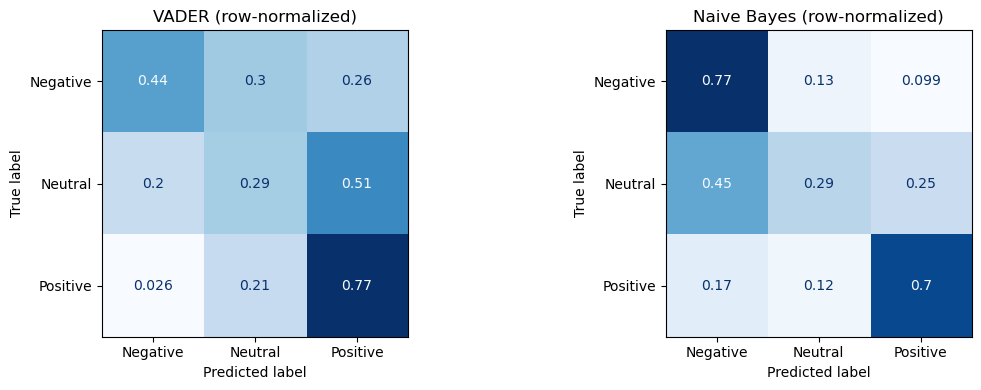

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

labels = ['Negative', 'Neutral', 'Positive']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_vader, labels=labels, ax=axes[0], cmap='Blues', normalize='true', colorbar=False
)
axes[0].set_title('VADER (row-normalized)')
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb, labels=labels, ax=axes[1], cmap='Blues', normalize='true', colorbar=False
)
axes[1].set_title('Naive Bayes (row-normalized)')
plt.tight_layout()
plt.show()

In [11]:
# Per-app macro F1 breakdown
test_df['nb_prediction'] = y_pred_nb

def per_app_f1(df, pred_col):
    rows = []
    for app in sorted(df['appName'].unique()):
        sub = df[df['appName'] == app]
        rows.append({
            'appName': app,
            'n': len(sub),
            'macro_f1': round(f1_score(sub['Sentiment'], sub[pred_col], average='macro'), 4),
        })
    return pd.DataFrame(rows)

print('VADER per-app macro F1:')
print(per_app_f1(test_df, 'vader_prediction').to_string(index=False))
print('\nNaive Bayes per-app macro F1:')
print(per_app_f1(test_df, 'nb_prediction').to_string(index=False))

VADER per-app macro F1:
appName    n  macro_f1
ChatGPT 1528    0.4670
 Claude  974    0.4632
 Gemini 1603    0.4851

Naive Bayes per-app macro F1:
appName    n  macro_f1
ChatGPT 1528    0.5292
 Claude  974    0.6542
 Gemini 1603    0.5616
